# Notebook 1 — Market Simulator & Classical Baselines

**Projet : Deep Hedging — Implémentation et comparaison**  
**Référence :** Buehler, Gonon, Teichmann, Wood (2018) — *Deep Hedging*

---

## Objectifs

Ce notebook constitue la **fondation du projet**. Il implémente :

1. Le simulateur de marché **Black-Scholes** (GBM)
2. Le simulateur de marché **Heston** (volatilité stochastique, échantillonnage exact CIR)
3. La stratégie de couverture **Black-Scholes delta hedge** (forme fermée)
4. La stratégie de couverture **Heston delta hedge** (différences finies)
5. Le calcul des **métriques de risque** : VaR, CVaR, turnover, coûts de transaction
6. La **comparaison quantitative** des deux baselines

Ces baselines serviront de référence pour évaluer le Deep Hedging dans le Notebook 2.

---

## Paramètres du projet (alignés sur le papier)

| Paramètre | Valeur | Description |
|-----------|--------|-------------|
| T | 30/365 | Horizon de temps (≈ 1 mois) |
| n | 30 | Nombre de pas de rebalancement quotidien |
| dt | 1/365 | Pas de temps |
| S₀ | 100 | Prix initial du sous-jacent |
| K | 100 | Strike (at-the-money) |
| r | 0.0 | Taux sans risque |
| ε | 0.01 | Coûts de transaction proportionnels |

---
## Section 0 — Imports et configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, ncx2
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────────────────────────
TRAIN_SEED = 42       # seed pour les paths d'entraînement
TEST_SEED  = 2024     # seed pour les paths out-of-sample (IDENTIQUE dans tous les notebooks)
np.random.seed(TRAIN_SEED)

# ── Paramètres globaux du projet ──────────────────────────────────────────────
T       = 30 / 365   # horizon ~1 mois
N_STEPS = 30         # rebalancement quotidien
DT      = T / N_STEPS
S0      = 100.0      # prix initial
K       = 100.0      # strike ATM
r       = 0.0        # taux sans risque
EPS     = 0.01       # coûts de transaction proportionnels (1%)

# ── Paramètres Heston (calibrés sur marché actions typique) ──────────────────
# Identiques au papier Buehler et al.
KAPPA = 1.0    # vitesse de retour à la moyenne
THETA = 0.04   # variance long-terme (vol long-terme = 20%)
XI    = 2.0    # vol-of-vol
RHO   = -0.7   # corrélation spot-variance (levier négatif)
V0    = 0.04   # variance initiale (vol initiale = 20%)

# ── Paramètres Black-Scholes ──────────────────────────────────────────────────
SIGMA_BS = np.sqrt(V0)  # 20% — cohérent avec Heston (même vol initiale)

# ── Tailles des échantillons ──────────────────────────────────────────────────
N_TRAIN = 100_000   # paths pour validation / visualisation
N_TEST  = 100_000   # paths out-of-sample

print(f"Horizon T = {T:.4f} ({N_STEPS} steps, dt = {DT:.4f})")
print(f"Vol initiale BS = {SIGMA_BS*100:.1f}%")
print(f"Heston : κ={KAPPA}, θ={THETA}, ξ={XI}, ρ={RHO}, V₀={V0}")
feller = 2*KAPPA*THETA/XI**2
feller_msg = 'satisfaite ✓' if feller > 1 else 'non satisfaite (V peut toucher 0 — cas du papier Buehler et al.)'
print(f'Feller condition (2κθ/ξ² > 1) : {feller:.3f} — {feller_msg}')

Horizon T = 0.0822 (30 steps, dt = 0.0027)
Vol initiale BS = 20.0%
Heston : κ=1.0, θ=0.04, ξ=2.0, ρ=-0.7, V₀=0.04
Feller condition (2κθ/ξ² > 1) : 0.020 — non satisfaite (V peut toucher 0 — cas du papier Buehler et al.)


---
## Section 1 — Simulateur Black-Scholes (GBM)

Le modèle Black-Scholes suppose que le prix suit un mouvement brownien géométrique :

$$dS_t = r S_t \, dt + \sigma S_t \, dW_t$$

La solution exacte est :

$$S_{t+dt} = S_t \exp\left[(r - \frac{\sigma^2}{2}) dt + \sigma \sqrt{dt} \, Z\right], \quad Z \sim \mathcal{N}(0,1)$$

In [2]:
def simulate_gbm(S0, r, sigma, T, n, M, seed=None):
    """
    Simulation exacte du mouvement brownien géométrique (Black-Scholes).

    Paramètres
    ----------
    S0    : float  — prix initial
    r     : float  — taux sans risque (drift risk-neutral)
    sigma : float  — volatilité
    T     : float  — horizon
    n     : int    — nombre de pas
    M     : int    — nombre de trajectoires
    seed  : int    — graine aléatoire pour reproductibilité

    Retourne
    --------
    S : np.ndarray shape (n+1, M)
        S[0] = S0 pour toutes les trajectoires
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n
    Z  = np.random.standard_normal((n, M))  # incréments browniens standardisés

    # Log-rendements
    log_increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    S = np.empty((n + 1, M))
    S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(log_increments, axis=0))

    return S

In [3]:
# ── Validation du simulateur GBM ─────────────────────────────────────────────
M_val = 200_000
S_bs_val = simulate_gbm(S0, r, SIGMA_BS, T, N_STEPS, M_val, seed=0)

# Test 1 : E[S_T] = S0 * exp(r*T) (mesure risk-neutre)
E_ST_theo = S0 * np.exp(r * T)
E_ST_mc   = S_bs_val[-1].mean()
print(f"[Validation GBM]")
print(f"  E[S_T] théorique : {E_ST_theo:.4f}")
print(f"  E[S_T] Monte Carlo: {E_ST_mc:.4f}")
print(f"  Erreur relative   : {abs(E_ST_mc - E_ST_theo)/E_ST_theo * 100:.4f}%")

# Test 2 : log(S_T/S0) ~ N((r-0.5σ²)T, σ²T)
log_ret = np.log(S_bs_val[-1] / S0)
mu_theo  = (r - 0.5 * SIGMA_BS**2) * T
std_theo = SIGMA_BS * np.sqrt(T)
print(f"  E[log S_T/S0] théorique : {mu_theo:.6f} | MC : {log_ret.mean():.6f}")
print(f"  Std[log S_T/S0] théorique: {std_theo:.6f} | MC : {log_ret.std():.6f}")

[Validation GBM]
  E[S_T] théorique : 100.0000
  E[S_T] Monte Carlo: 100.0094
  Erreur relative   : 0.0094%
  E[log S_T/S0] théorique : -0.001644 | MC : -0.001548
  Std[log S_T/S0] théorique: 0.057338 | MC : 0.057310


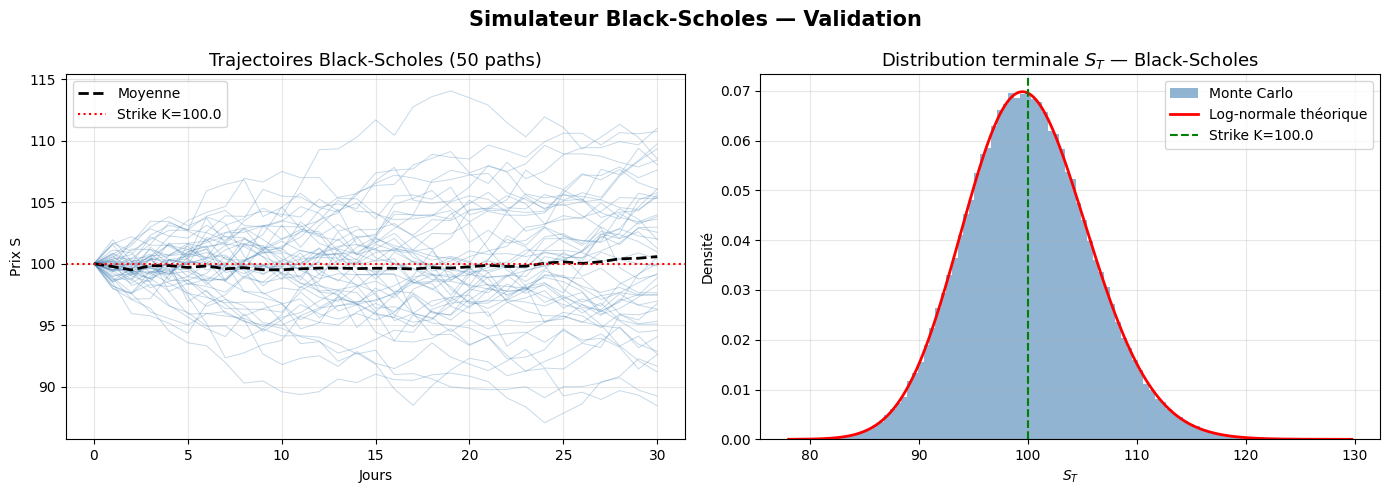

In [4]:
# ── Visualisation des trajectoires GBM ───────────────────────────────────────
S_bs_plot = simulate_gbm(S0, r, SIGMA_BS, T, N_STEPS, M=500, seed=TRAIN_SEED)
t_grid = np.linspace(0, T, N_STEPS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trajectoires
axes[0].plot(t_grid * 365, S_bs_plot[:, :50], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].plot(t_grid * 365, S_bs_plot[:, :50].mean(axis=1), 'k--', linewidth=2, label='Moyenne')
axes[0].axhline(K, color='red', linestyle=':', linewidth=1.5, label=f'Strike K={K}')
axes[0].set_title('Trajectoires Black-Scholes (50 paths)', fontsize=13)
axes[0].set_xlabel('Jours')
axes[0].set_ylabel('Prix S')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution terminale
axes[1].hist(S_bs_val[-1], bins=100, density=True, alpha=0.6, color='steelblue', label='Monte Carlo')
x = np.linspace(S_bs_val[-1].min(), S_bs_val[-1].max(), 300)
mu_ln  = np.log(S0) + (r - 0.5*SIGMA_BS**2)*T
sig_ln = SIGMA_BS * np.sqrt(T)
pdf_ln = (1/(x * sig_ln * np.sqrt(2*np.pi))) * np.exp(-0.5*((np.log(x) - mu_ln)/sig_ln)**2)
axes[1].plot(x, pdf_ln, 'r-', linewidth=2, label='Log-normale théorique')
axes[1].axvline(K, color='green', linestyle='--', label=f'Strike K={K}')
axes[1].set_title('Distribution terminale $S_T$ — Black-Scholes', fontsize=13)
axes[1].set_xlabel('$S_T$')
axes[1].set_ylabel('Densité')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Simulateur Black-Scholes — Validation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2 — Simulateur Heston (échantillonnage exact)

Le modèle de Heston (1993) est un modèle à volatilité stochastique :

$$dS_t = r S_t \, dt + \sqrt{V_t} \, S_t \, dB_t$$
$$dV_t = \kappa (\theta - V_t) \, dt + \xi \sqrt{V_t} \, dW_t$$
$$d\langle B, W \rangle_t = \rho \, dt$$

où $V_t$ suit un processus **CIR** (Cox-Ingersoll-Ross). La **condition de Feller** $2\kappa\theta > \xi^2$ garantit que $V_t > 0$ p.s.

### Échantillonnage exact du CIR

La distribution de $V_{t+\Delta t} | V_t$ est une **chi-2 non-centrale** :
$$V_{t+\Delta t} | V_t \sim c \cdot \chi^2(d, \lambda)$$
avec $c = \frac{\xi^2(1-e^{-\kappa\Delta t})}{4\kappa}$, $d = \frac{4\kappa\theta}{\xi^2}$, $\lambda = \frac{V_t e^{-\kappa\Delta t}}{c}$

In [5]:
def sample_cir_exact(V_t, kappa, theta, xi, dt, M=None):
    """
    Echantillonnage exact de V_{t+dt} | V_t via la loi chi-2 non-centrale.
    Référence : Glasserman (2004), Section 3.4.

    Paramètres
    ----------
    V_t   : float ou np.ndarray — variance courante
    kappa : float — vitesse de retour à la moyenne
    theta : float — variance long-terme
    xi    : float — vol-of-vol
    dt    : float — pas de temps
    M     : int   — nombre de trajectoires (si V_t est scalaire)

    Retourne
    --------
    V_{t+dt} : np.ndarray
    """
    # Paramètres de la loi chi-2 non-centrale
    c   = xi**2 * (1 - np.exp(-kappa * dt)) / (4 * kappa)
    d   = 4 * kappa * theta / xi**2          # degrés de liberté
    lam = V_t * np.exp(-kappa * dt) / c      # paramètre de non-centralité

    size = M if M is not None else V_t.shape
    V_next = c * ncx2.rvs(df=d, nc=lam, size=size)
    return np.maximum(V_next, 1e-10)  # éviter V=0 numériquement


def simulate_heston(S0, V0, kappa, theta, xi, rho, r, T, n, M, seed=None):
    """
    Simulation du modèle de Heston avec échantillonnage exact du CIR.
    Le processus S est simulé par le schéma de Broadie-Kaya simplifié.

    Paramètres
    ----------
    S0, V0         : float  — conditions initiales
    kappa, theta,
    xi, rho        : float  — paramètres Heston
    r              : float  — taux sans risque
    T, n, M        : float, int, int — horizon, pas, trajectoires
    seed           : int    — graine

    Retourne
    --------
    S : np.ndarray (n+1, M)  — trajectoires du prix
    V : np.ndarray (n+1, M)  — trajectoires de la variance
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n
    S  = np.empty((n + 1, M))
    V  = np.empty((n + 1, M))
    S[0] = S0
    V[0] = V0

    for t in range(n):
        # 1) Echantillonnage exact de V_{t+1} | V_t
        V[t + 1] = sample_cir_exact(V[t], kappa, theta, xi, dt)

        # 2) Browniens corrélés pour S
        #    B_S = rho * W_V + sqrt(1-rho^2) * W_perp
        Z1 = np.random.standard_normal(M)   # composante commune
        Z2 = np.random.standard_normal(M)   # composante orthogonale
        dW_S = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        # 3) Schéma log-Euler pour S (utilise V[t] comme approximation de l'intégrale)
        S[t + 1] = S[t] * np.exp(
            (r - 0.5 * V[t]) * dt + np.sqrt(np.maximum(V[t], 0) * dt) * dW_S
        )

    return S, V

In [6]:
# ── Validation du simulateur Heston ──────────────────────────────────────────
M_val = 200_000
S_h_val, V_h_val = simulate_heston(
    S0, V0, KAPPA, THETA, XI, RHO, r, T, N_STEPS, M_val, seed=0
)

print("[Validation Heston]")
# Test 1 : E[S_T] = S0 * exp(r*T) sous Q
print(f"  E[S_T] théorique : {S0*np.exp(r*T):.4f}")
print(f"  E[S_T] MC        : {S_h_val[-1].mean():.4f}")

# Test 2 : E[V_T] = V0*exp(-κT) + θ*(1-exp(-κT)) (moyenne CIR)
E_VT_theo = V0 * np.exp(-KAPPA*T) + THETA * (1 - np.exp(-KAPPA*T))
print(f"  E[V_T] théorique : {E_VT_theo:.6f}")
print(f"  E[V_T] MC        : {V_h_val[-1].mean():.6f}")

# Test 3 : Var[V_T] = V0*(ξ²/κ)*(exp(-κT)-exp(-2κT)) + θ*ξ²/(2κ)*(1-exp(-κT))²
Var_VT_theo = V0*(XI**2/KAPPA)*(np.exp(-KAPPA*T)-np.exp(-2*KAPPA*T)) + \
              THETA*XI**2/(2*KAPPA)*(1-np.exp(-KAPPA*T))**2
print(f"  Var[V_T] théorique: {Var_VT_theo:.8f}")
print(f"  Var[V_T] MC       : {V_h_val[-1].var():.8f}")

[Validation Heston]
  E[S_T] théorique : 100.0000
  E[S_T] MC        : 100.0077
  E[V_T] théorique : 0.040000
  E[V_T] MC        : 0.040453
  Var[V_T] théorique: 0.01212668
  Var[V_T] MC       : 0.01231696


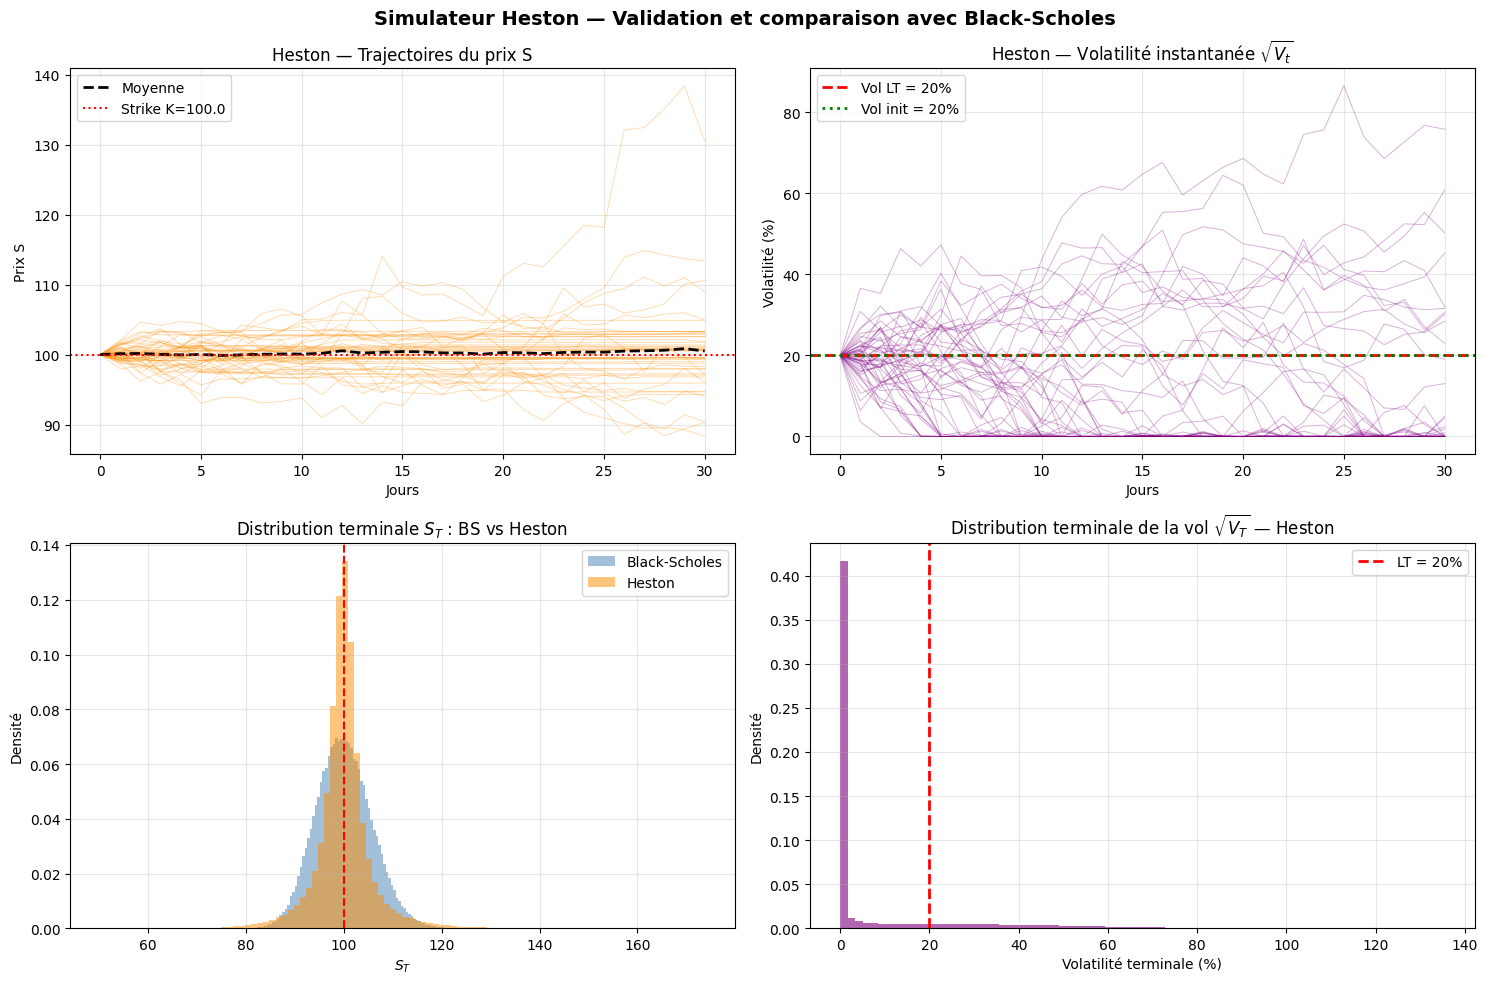

In [7]:
# ── Visualisation Heston ──────────────────────────────────────────────────────
n_plot = 100
S_h_plot, V_h_plot = simulate_heston(
    S0, V0, KAPPA, THETA, XI, RHO, r, T, N_STEPS, n_plot, seed=TRAIN_SEED
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Trajectoires S
axes[0, 0].plot(t_grid*365, S_h_plot[:, :50], alpha=0.3, linewidth=0.7, color='darkorange')
axes[0, 0].plot(t_grid*365, S_h_plot[:, :50].mean(axis=1), 'k--', lw=2, label='Moyenne')
axes[0, 0].axhline(K, color='red', ls=':', lw=1.5, label=f'Strike K={K}')
axes[0, 0].set_title('Heston — Trajectoires du prix S', fontsize=12)
axes[0, 0].set_xlabel('Jours'); axes[0, 0].set_ylabel('Prix S')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Trajectoires V (variance)
axes[0, 1].plot(t_grid*365, np.sqrt(V_h_plot[:, :50])*100, alpha=0.3, lw=0.7, color='purple')
axes[0, 1].axhline(np.sqrt(THETA)*100, color='red', ls='--', lw=2, label=f'Vol LT = {np.sqrt(THETA)*100:.0f}%')
axes[0, 1].axhline(np.sqrt(V0)*100, color='green', ls=':', lw=2, label=f'Vol init = {np.sqrt(V0)*100:.0f}%')
axes[0, 1].set_title('Heston — Volatilité instantanée $\\sqrt{V_t}$', fontsize=12)
axes[0, 1].set_xlabel('Jours'); axes[0, 1].set_ylabel('Volatilité (%)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution terminale S_T : BS vs Heston
S_bs_200k = simulate_gbm(S0, r, SIGMA_BS, T, N_STEPS, 200_000, seed=0)
axes[1, 0].hist(S_bs_200k[-1], bins=100, density=True, alpha=0.5, color='steelblue', label='Black-Scholes')
axes[1, 0].hist(S_h_val[-1], bins=100, density=True, alpha=0.5, color='darkorange', label='Heston')
axes[1, 0].axvline(K, color='red', ls='--', lw=1.5)
axes[1, 0].set_title('Distribution terminale $S_T$ : BS vs Heston', fontsize=12)
axes[1, 0].set_xlabel('$S_T$'); axes[1, 0].set_ylabel('Densité')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 4. Distribution de V_T
axes[1, 1].hist(np.sqrt(V_h_val[-1])*100, bins=80, density=True, color='purple', alpha=0.6)
axes[1, 1].axvline(np.sqrt(THETA)*100, color='red', ls='--', lw=2, label=f'LT = {np.sqrt(THETA)*100:.0f}%')
axes[1, 1].set_title('Distribution terminale de la vol $\\sqrt{V_T}$ — Heston', fontsize=12)
axes[1, 1].set_xlabel('Volatilité terminale (%)'); axes[1, 1].set_ylabel('Densité')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Simulateur Heston — Validation et comparaison avec Black-Scholes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Formules Black-Scholes

### Prix et grecques en forme fermée

$$C_{BS}(S, t) = S \, N(d_1) - K e^{-r(T-t)} N(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)(T-t)}{\sigma\sqrt{T-t}}, \quad d_2 = d_1 - \sigma\sqrt{T-t}$$

$$\Delta_{BS} = \frac{\partial C}{\partial S} = N(d_1)$$

In [8]:
def bs_call_price(S, K, tau, r, sigma):
    """
    Prix d'un call européen par la formule de Black-Scholes.

    Paramètres : tau = T - t (time-to-maturity)
    Gère vectoriellement S et tau via numpy.
    """
    S     = np.atleast_1d(np.asarray(S, dtype=float))
    tau   = np.atleast_1d(np.asarray(tau, dtype=float))

    price = np.where(
        tau <= 0,
        np.maximum(S - K, 0.0),
        S * norm.cdf((np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau)))
        - K * np.exp(-r*tau) * norm.cdf(
            (np.log(S/K) + (r - 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
        )
    )
    return price


def bs_delta(S, K, tau, r, sigma):
    """
    Delta d'un call européen Black-Scholes : ∂C/∂S = N(d1).
    """
    S   = np.atleast_1d(np.asarray(S, dtype=float))
    tau = np.atleast_1d(np.asarray(tau, dtype=float))

    delta = np.where(
        tau <= 0,
        (S > K).astype(float),
        norm.cdf((np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau)))
    )
    return delta


def bs_gamma(S, K, tau, r, sigma):
    """
    Gamma d'un call européen Black-Scholes : ∂²C/∂S² = N'(d1) / (S σ √τ).
    """
    S   = np.atleast_1d(np.asarray(S, dtype=float))
    tau = np.atleast_1d(np.asarray(tau, dtype=float))

    gamma = np.where(
        tau <= 0, 0.0,
        norm.pdf((np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau)))
        / (S * sigma * np.sqrt(tau))
    )
    return gamma

In [9]:
# ── Tests de validation des formules BS ──────────────────────────────────────
S_test  = 100.0
K_test  = 100.0
tau_test = float(T)
r_test  = float(r)
sig_test = float(SIGMA_BS)

C = bs_call_price(S_test, K_test, tau_test, r_test, sig_test).squeeze().item()
d = bs_delta(S_test, K_test, tau_test, r_test, sig_test).squeeze().item()
g = bs_gamma(S_test, K_test, tau_test, r_test, sig_test).squeeze().item()

# Parité call-put : C - P = S - K*exp(-rT)  =>  P = C - S + K*exp(-rT)
discount = float(np.exp(-r_test * tau_test))
P_val       = C - S_test + K_test * discount
parity_check = C - P_val - (S_test - K_test * discount)

print("[Validation formules Black-Scholes]")
print(f"  Prix call C₀         : {C:.6f}")
print(f"  Prix put P₀          : {P_val:.6f}")
print(f"  Parité call-put (≈0) : {parity_check:.2e}")
print(f"  Delta Δ              : {d:.6f}  (ATM ≈ 0.5)")
print(f"  Gamma Γ              : {g:.6f}")

# Prix par Monte Carlo pour vérifier
S_mc = simulate_gbm(S_test, r_test, sig_test, tau_test, N_STEPS, 500_000, seed=0)
C_mc = float(np.exp(-r_test * tau_test)) * float(np.maximum(S_mc[-1] - K_test, 0).mean())
print(f"\n  Prix call MC (500k)  : {C_mc:.6f}")
print(f"  Erreur relative MC   : {abs(C_mc - C)/C*100:.4f}%")

[Validation formules Black-Scholes]
  Prix call C₀         : 2.287151
  Prix put P₀          : 2.287151
  Parité call-put (≈0) : 0.00e+00
  Delta Δ              : 0.511436  (ATM ≈ 0.5)
  Gamma Γ              : 0.069548

  Prix call MC (500k)  : 2.285629
  Erreur relative MC   : 0.0665%


---
## Section 4 — Delta Heston par différences finies

Dans le modèle de Heston, il n'existe pas de formule fermée simple pour le delta.
On utilise l'approximation par **différences finies centrées** :

$$\Delta^{Heston}(S, V, \tau) \approx \frac{C(S+\varepsilon, V, \tau) - C(S-\varepsilon, V, \tau)}{2\varepsilon}$$

Le prix $C(S, V, \tau)$ est estimé par Monte Carlo avec un seed fixe pour réduire le bruit.

In [10]:
def heston_call_mc(S0_val, V0_val, K, tau, r, kappa, theta, xi, rho,
                   n_steps=30, M_inner=20_000, seed=99):
    """
    Prix Monte Carlo d'un call européen sous Heston.
    Utilisé comme brique de base pour le calcul numérique des grecques.
    """
    if tau <= 0:
        return float(np.maximum(S0_val - K, 0))
    S, _ = simulate_heston(
        S0_val, V0_val, kappa, theta, xi, rho, r,
        tau, n_steps, M_inner, seed=seed
    )
    return float(np.exp(-r * tau) * np.maximum(S[-1] - K, 0).mean())


def heston_delta_fd(S_val, V_val, K, tau, r, kappa, theta, xi, rho,
                    eps_fd=1.0, n_steps=30, M_inner=20_000, seed=99):
    """
    Delta Heston par différences finies centrées.

    eps_fd : perturbation en points de prix (défaut 1.0 = 1% d'un spot à 100)
    """
    if tau <= 0:
        return float(S_val > K)

    p_up = heston_call_mc(S_val + eps_fd, V_val, K, tau, r,
                          kappa, theta, xi, rho, n_steps, M_inner, seed)
    p_dn = heston_call_mc(S_val - eps_fd, V_val, K, tau, r,
                          kappa, theta, xi, rho, n_steps, M_inner, seed)
    return (p_up - p_dn) / (2 * eps_fd)


# ── Test et comparaison BS vs Heston delta ────────────────────────────────────
print("[Delta Heston vs Black-Scholes — point de test ATM]")
tau_test = T

delta_bs_atm = bs_delta(S0, K, tau_test, r, SIGMA_BS).item()
delta_hs_atm = heston_delta_fd(S0, V0, K, tau_test, r, KAPPA, THETA, XI, RHO)

print(f"  Δ_BS  (ATM, σ=20%) : {delta_bs_atm:.4f}")
print(f"  Δ_Heston (ATM)     : {delta_hs_atm:.4f}")
print(f"  Différence         : {abs(delta_bs_atm - delta_hs_atm):.4f}")
print("  Note : les différences reflètent l'effet du levier (ρ=-0.7) en Heston")

[Delta Heston vs Black-Scholes — point de test ATM]
  Δ_BS  (ATM, σ=20%) : 0.5114
  Δ_Heston (ATM)     : 0.5148
  Différence         : 0.0034
  Note : les différences reflètent l'effet du levier (ρ=-0.7) en Heston


---
## Section 5 — Moteur de Delta Hedging

### P&L d'une stratégie de delta hedge

On vend un call en t=0 au prix $C_0$ et on couvre dynamiquement.
Le **compte de cash** évolue selon :

$$B_{t_k} = B_{t_{k-1}} e^{r \, dt} - (\delta_{t_k} - \delta_{t_{k-1}}) S_{t_k} - C_T(\delta_{t_k} - \delta_{t_{k-1}})$$

Le **P&L terminal** (terminal hedging error) est :

$$\text{PnL}_T = -\underbrace{(S_T - K)^+}_{\text{paiement option}} + \underbrace{\delta_{T-} S_T}_{\text{position stock}} + B_T$$

Les **coûts de transaction proportionnels** (Buehler et al., Eq. 5.7) :

$$C_T(\delta) = \sum_{k=0}^{n} \varepsilon |\delta_{t_k} - \delta_{t_{k-1}}| \cdot S_{t_k}$$

In [11]:
def run_delta_hedge(S_paths, delta_fn, C0, K, r, T, n, eps_tc=0.0):
    """
    Simule une stratégie de delta hedge sur un ensemble de trajectoires.

    Paramètres
    ----------
    S_paths  : np.ndarray (n+1, M) — trajectoires du sous-jacent
    delta_fn : callable(S, tau, path_idx) -> float/array — fonction delta
    C0       : float — prix initial du call (prime reçue)
    K        : float — strike
    r        : float — taux sans risque
    T        : float — horizon
    n        : int   — nombre de pas
    eps_tc   : float — coût de transaction proportionnel

    Retourne
    --------
    pnl       : np.ndarray (M,)      — P&L terminal
    cash      : np.ndarray (n+1, M)  — évolution du compte cash
    deltas    : np.ndarray (n+1, M)  — positions delta
    tc_total  : np.ndarray (M,)      — coûts de transaction cumulés
    turnover  : np.ndarray (M,)      — turnover total (Σ|Δδ|·S)
    """
    dt  = T / n
    M   = S_paths.shape[1]

    cash    = np.zeros((n + 1, M))
    deltas  = np.zeros((n + 1, M))
    tc_cum  = np.zeros(M)    # coûts cumulés
    turnover= np.zeros(M)    # Σ|Δδ|·S

    # ── t=0 : vente du call, achat du delta initial ──────────────────────────
    tau0         = T
    deltas[0]    = delta_fn(S_paths[0], tau0)
    tc_init      = eps_tc * np.abs(deltas[0]) * S_paths[0]  # coût sur position initiale
    cash[0]      = C0 - deltas[0] * S_paths[0] - tc_init
    tc_cum      += tc_init
    turnover    += np.abs(deltas[0]) * S_paths[0]

    # ── Rebalancement dynamique ──────────────────────────────────────────────
    for t in range(1, n + 1):
        # Intérêt sur le cash
        cash[t] = cash[t - 1] * np.exp(r * dt)

        # Calcul du nouveau delta (0 à maturité)
        tau_t       = T - t * dt
        deltas[t]   = delta_fn(S_paths[t], max(tau_t, 0.0))

        # Changement de position
        d_delta     = deltas[t] - deltas[t - 1]

        # Coûts de transaction : ε * |Δδ| * S_t  (Buehler et al. eq. 5.7)
        tc_step     = eps_tc * np.abs(d_delta) * S_paths[t]

        # Mise à jour du cash
        cash[t]    -= d_delta * S_paths[t] + tc_step

        # Accumulation
        tc_cum     += tc_step
        turnover   += np.abs(d_delta) * S_paths[t]

    # ── P&L terminal : cash final + position stock - payoff option ────────────
    payoff = np.maximum(S_paths[-1] - K, 0.0)
    pnl    = cash[-1] + deltas[-1] * S_paths[-1] - payoff

    return pnl, cash, deltas, tc_cum, turnover

---
## Section 6 — Métriques de risque

Conformément aux exigences du projet, on calcule :

- **VaR** (Value at Risk) à 95% et 99%
- **CVaR** (Conditional VaR / Expected Shortfall) à 95% et 99%
- **Turnover moyen** et **coûts de transaction**

In [12]:
def compute_risk_metrics(pnl, tc_total=None, turnover=None, label=""):
    """
    Calcule et affiche les métriques de risque d'une distribution de P&L.

    Convention : pnl > 0 = gain. VaR et CVaR sont des pertes (signe positif = risque).

    Retourne un dict avec toutes les métriques.
    """
    n = len(pnl)

    # ── Statistiques descriptives ──────────────────────────────────────────────
    mean_pnl = pnl.mean()
    std_pnl  = pnl.std()
    skew     = ((pnl - mean_pnl)**3).mean() / std_pnl**3 if std_pnl > 0 else 0
    kurt     = ((pnl - mean_pnl)**4).mean() / std_pnl**4 - 3 if std_pnl > 0 else 0

    # ── VaR et CVaR ───────────────────────────────────────────────────────────
    def var(alpha):
        return float(-np.percentile(pnl, (1 - alpha) * 100))

    def cvar(alpha):
        v = var(alpha)
        losses = -pnl[pnl <= -v]
        return float(losses.mean()) if len(losses) > 0 else v

    var95  = var(0.95);  cvar95 = cvar(0.95)
    var99  = var(0.99);  cvar99 = cvar(0.99)

    # ── Coûts et turnover ────────────────────────────────────────────────────
    mean_tc = tc_total.mean()   if tc_total  is not None else np.nan
    mean_to = turnover.mean()   if turnover  is not None else np.nan

    metrics = {
        'label'    : label,
        'mean_pnl' : mean_pnl,
        'std_pnl'  : std_pnl,
        'skewness' : skew,
        'kurtosis' : kurt,
        'var95'    : var95,
        'cvar95'   : cvar95,
        'var99'    : var99,
        'cvar99'   : cvar99,
        'mean_tc'  : mean_tc,
        'mean_to'  : mean_to,
        'n_paths'  : n,
    }

    # ── Affichage ──────────────────────────────────────────────────────────────
    title = f"  Métriques de risque — {label}" if label else "  Métriques de risque"
    sep   = "─" * 50
    print(f"\n{sep}")
    print(title)
    print(sep)
    print(f"  Nb trajectoires  : {n:>10,}")
    print(f"  Moyenne P&L      : {mean_pnl:>10.4f}")
    print(f"  Écart-type P&L   : {std_pnl:>10.4f}")
    print(f"  Skewness         : {skew:>10.4f}")
    print(f"  Kurtosis excès   : {kurt:>10.4f}")
    print(f"  VaR  95%         : {var95:>10.4f}")
    print(f"  CVaR 95%         : {cvar95:>10.4f}")
    print(f"  VaR  99%         : {var99:>10.4f}")
    print(f"  CVaR 99%         : {cvar99:>10.4f}")
    if not np.isnan(mean_tc):
        print(f"  Coûts trans. moy.: {mean_tc:>10.4f}")
        print(f"  Turnover moyen   : {mean_to:>10.4f}")
    print(sep)

    return metrics

---
## Section 7 — Évaluation : Black-Scholes Delta Hedge

### 7.1 Génération des paths out-of-sample

**Important** : on utilise `TEST_SEED` pour tous les modèles afin d'avoir une comparaison équitable.

In [13]:
# ── Génération des paths out-of-sample communs ────────────────────────────────
print(f"Génération de {N_TEST:,} trajectoires out-of-sample (seed={TEST_SEED})...")

# Black-Scholes
S_bs_test = simulate_gbm(S0, r, SIGMA_BS, T, N_STEPS, N_TEST, seed=TEST_SEED)

# Heston
S_heston_test, V_heston_test = simulate_heston(
    S0, V0, KAPPA, THETA, XI, RHO, r, T, N_STEPS, N_TEST, seed=TEST_SEED
)

# Prix initiaux des options
C0_bs     = bs_call_price(S0, K, T, r, SIGMA_BS).item()
C0_heston = heston_call_mc(S0, V0, K, T, r, KAPPA, THETA, XI, RHO,
                           n_steps=N_STEPS, M_inner=200_000, seed=0)

print(f"\nPrix call Black-Scholes : {C0_bs:.4f}")
print(f"Prix call Heston (MC)   : {C0_heston:.4f}")
print(f"Différence              : {abs(C0_bs - C0_heston):.4f}")

Génération de 100,000 trajectoires out-of-sample (seed=2024)...

Prix call Black-Scholes : 2.2872
Prix call Heston (MC)   : 1.8369
Différence              : 0.4502


In [14]:
# ── BS delta hedge sur paths BS (cas idéal : modèle correct) ─────────────────
print("=" * 60)
print("EXPÉRIENCE 1 : BS delta hedge sur paths Black-Scholes")
print("=" * 60)

# Cas 1a : sans coûts de transaction
delta_bs_fn = lambda S, tau: bs_delta(S, K, tau, r, SIGMA_BS).flatten()

pnl_bs_notc, cash_bs_notc, del_bs_notc, tc_bs_notc, to_bs_notc = run_delta_hedge(
    S_bs_test, delta_bs_fn, C0_bs, K, r, T, N_STEPS, eps_tc=0.0
)
m_bs_notc = compute_risk_metrics(
    pnl_bs_notc, tc_bs_notc, to_bs_notc,
    label="BS Δ-hedge | paths BS | sans TC"
)

# Cas 1b : avec coûts de transaction ε=1%
pnl_bs_tc, cash_bs_tc, del_bs_tc, tc_bs_tc, to_bs_tc = run_delta_hedge(
    S_bs_test, delta_bs_fn, C0_bs, K, r, T, N_STEPS, eps_tc=EPS
)
m_bs_tc = compute_risk_metrics(
    pnl_bs_tc, tc_bs_tc, to_bs_tc,
    label=f"BS Δ-hedge | paths BS | TC={EPS*100:.0f}%"
)

EXPÉRIENCE 1 : BS delta hedge sur paths Black-Scholes

──────────────────────────────────────────────────
  Métriques de risque — BS Δ-hedge | paths BS | sans TC
──────────────────────────────────────────────────
  Nb trajectoires  :    100,000
  Moyenne P&L      :    -0.0012
  Écart-type P&L   :     0.3587
  Skewness         :    -0.2859
  Kurtosis excès   :     1.6946
  VaR  95%         :     0.5926
  CVaR 95%         :     0.8382
  VaR  99%         :     0.9846
  CVaR 99%         :     1.2409
  Coûts trans. moy.:     0.0000
  Turnover moyen   :   230.4742
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Métriques de risque — BS Δ-hedge | paths BS | TC=1%
──────────────────────────────────────────────────
  Nb trajectoires  :    100,000
  Moyenne P&L      :    -2.3060
  Écart-type P&L   :     0.8243
  Skewness         :    -0.8201
  Kurtosis excès   :     0.6078
  VaR  95%         :     3.8485
  CVaR 95%         :     4.3392
  V

---
## Section 8 — Évaluation : Heston Delta Hedge

Le delta Heston est pré-calculé sur une **grille (S, V, τ)** pour éviter un calcul Monte Carlo
coûteux à chaque pas de temps. On interpole ensuite sur les trajectoires simulées.

In [15]:
# ── Pré-calcul de la grille de delta Heston ───────────────────────────────────
# Grille adaptée à la dynamique Heston observée dans les simulations
S_grid   = np.linspace(80, 120, 20)       # spots plausibles
V_grid   = np.linspace(0.01, 0.12, 10)    # variances plausibles
tau_grid = np.array([k * DT for k in range(N_STEPS, -1, -1)])  # τ de T à 0

print(f"Grille delta Heston : {len(S_grid)} × {len(V_grid)} × {len(tau_grid)} = "
      f"{len(S_grid)*len(V_grid)*len(tau_grid):,} points")
print("Calcul en cours (quelques minutes)...")

# Cache du delta
delta_grid_heston = np.zeros((len(S_grid), len(V_grid), len(tau_grid)))

for i, s in enumerate(S_grid):
    for j, v in enumerate(V_grid):
        for k, tau in enumerate(tau_grid):
            delta_grid_heston[i, j, k] = heston_delta_fd(
                s, v, K, tau, r, KAPPA, THETA, XI, RHO,
                eps_fd=0.5, n_steps=N_STEPS, M_inner=10_000, seed=99
            )

print("Grille calculée ✓")
print(f"Delta Heston (S=100, V=0.04, τ=T) = {delta_grid_heston[10, 3, 0]:.4f}")

Grille delta Heston : 20 × 10 × 31 = 6,200 points
Calcul en cours (quelques minutes)...
Grille calculée ✓
Delta Heston (S=100, V=0.04, τ=T) = 0.6394


In [16]:
from scipy.interpolate import RegularGridInterpolator

# ── Interpolateur trilinéaire ─────────────────────────────────────────────────
heston_delta_interp = RegularGridInterpolator(
    (S_grid, V_grid, tau_grid),
    delta_grid_heston,
    method='linear',
    bounds_error=False,
    fill_value=None   # extrapolation linéaire hors grille
)


def heston_delta_on_paths(S_vals, tau_val, V_vals):
    """
    Évalue le delta Heston interpolé pour un vecteur de (S, V) au temps τ.

    Paramètres
    ----------
    S_vals  : np.ndarray (M,)
    tau_val : float
    V_vals  : np.ndarray (M,)

    Retourne
    --------
    delta : np.ndarray (M,)
    """
    M = len(S_vals)
    pts = np.stack([
        np.clip(S_vals, S_grid.min(), S_grid.max()),
        np.clip(V_vals, V_grid.min(), V_grid.max()),
        np.full(M, max(tau_val, 0.0))
    ], axis=1)
    return np.clip(heston_delta_interp(pts), 0.0, 1.0)

In [17]:
# ── Heston delta hedge sur paths Heston ──────────────────────────────────────
print("=" * 60)
print("EXPÉRIENCE 2 : Heston delta hedge sur paths Heston")
print("=" * 60)

def run_heston_delta_hedge(S_paths, V_paths, C0, K, r, T, n, eps_tc=0.0):
    """
    Version spécialisée qui passe V_paths à la fonction de delta Heston.
    """
    dt  = T / n
    M   = S_paths.shape[1]

    cash    = np.zeros((n + 1, M))
    deltas  = np.zeros((n + 1, M))
    tc_cum  = np.zeros(M)
    turnover= np.zeros(M)

    tau0      = T
    deltas[0] = heston_delta_on_paths(S_paths[0], tau0, V_paths[0])
    tc_init   = eps_tc * np.abs(deltas[0]) * S_paths[0]
    cash[0]   = C0 - deltas[0] * S_paths[0] - tc_init
    tc_cum   += tc_init
    turnover += np.abs(deltas[0]) * S_paths[0]

    for t in range(1, n + 1):
        cash[t]   = cash[t - 1] * np.exp(r * dt)
        tau_t     = max(T - t * dt, 0.0)
        deltas[t] = heston_delta_on_paths(S_paths[t], tau_t, V_paths[t])

        d_delta   = deltas[t] - deltas[t - 1]
        tc_step   = eps_tc * np.abs(d_delta) * S_paths[t]
        cash[t]  -= d_delta * S_paths[t] + tc_step
        tc_cum   += tc_step
        turnover += np.abs(d_delta) * S_paths[t]

    payoff = np.maximum(S_paths[-1] - K, 0.0)
    pnl    = cash[-1] + deltas[-1] * S_paths[-1] - payoff

    return pnl, cash, deltas, tc_cum, turnover


# Cas 2a : sans coûts
pnl_hs_notc, _, del_hs_notc, tc_hs_notc, to_hs_notc = run_heston_delta_hedge(
    S_heston_test, V_heston_test, C0_heston, K, r, T, N_STEPS, eps_tc=0.0
)
m_hs_notc = compute_risk_metrics(
    pnl_hs_notc, tc_hs_notc, to_hs_notc,
    label="Heston Δ-hedge | paths Heston | sans TC"
)

# Cas 2b : avec coûts
pnl_hs_tc, _, del_hs_tc, tc_hs_tc, to_hs_tc = run_heston_delta_hedge(
    S_heston_test, V_heston_test, C0_heston, K, r, T, N_STEPS, eps_tc=EPS
)
m_hs_tc = compute_risk_metrics(
    pnl_hs_tc, tc_hs_tc, to_hs_tc,
    label=f"Heston Δ-hedge | paths Heston | TC={EPS*100:.0f}%"
)

EXPÉRIENCE 2 : Heston delta hedge sur paths Heston

──────────────────────────────────────────────────
  Métriques de risque — Heston Δ-hedge | paths Heston | sans TC
──────────────────────────────────────────────────
  Nb trajectoires  :    100,000
  Moyenne P&L      :     0.0146
  Écart-type P&L   :     1.5300
  Skewness         :    -1.9886
  Kurtosis excès   :     7.1184
  VaR  95%         :     2.9095
  CVaR 95%         :     4.3898
  VaR  99%         :     5.2712
  CVaR 99%         :     7.0078
  Coûts trans. moy.:     0.0000
  Turnover moyen   :   180.6245
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Métriques de risque — Heston Δ-hedge | paths Heston | TC=1%
──────────────────────────────────────────────────
  Nb trajectoires  :    100,000
  Moyenne P&L      :    -1.7916
  Écart-type P&L   :     2.1913
  Skewness         :    -1.7075
  Kurtosis excès   :     4.6427
  VaR  95%         :     6.0377
  CVaR 95%         :  

---
## Section 9 — Comparaison quantitative et visualisations

### 9.1 Table de synthèse

In [18]:
# ── Table de synthèse ─────────────────────────────────────────────────────────
all_metrics = [m_bs_notc, m_bs_tc, m_hs_notc, m_hs_tc]

header = f"{'Stratégie':<45} {'Mean PnL':>9} {'Std':>8} {'VaR95':>8} {'CVaR95':>8} {'VaR99':>8} {'CVaR99':>8} {'TC moy':>8}"
print("\n" + "═"*105)
print("TABLE DE SYNTHÈSE — BASELINES CLASSIQUES")
print("═"*105)
print(header)
print("─"*105)
for m in all_metrics:
    tc_str = f"{m['mean_tc']:>8.4f}" if not np.isnan(m['mean_tc']) else "     N/A"
    print(f"{m['label']:<45} {m['mean_pnl']:>9.4f} {m['std_pnl']:>8.4f} "
          f"{m['var95']:>8.4f} {m['cvar95']:>8.4f} {m['var99']:>8.4f} {m['cvar99']:>8.4f} {tc_str}")
print("═"*105)


═════════════════════════════════════════════════════════════════════════════════════════════════════════
TABLE DE SYNTHÈSE — BASELINES CLASSIQUES
═════════════════════════════════════════════════════════════════════════════════════════════════════════
Stratégie                                      Mean PnL      Std    VaR95   CVaR95    VaR99   CVaR99   TC moy
─────────────────────────────────────────────────────────────────────────────────────────────────────────
BS Δ-hedge | paths BS | sans TC                 -0.0012   0.3587   0.5926   0.8382   0.9846   1.2409   0.0000
BS Δ-hedge | paths BS | TC=1%                   -2.3060   0.8243   3.8485   4.3392   4.6386   5.0684   2.3047
Heston Δ-hedge | paths Heston | sans TC          0.0146   1.5300   2.9095   4.3898   5.2712   7.0078   0.0000
Heston Δ-hedge | paths Heston | TC=1%           -1.7916   2.1913   6.0377   7.9750   9.1333  11.2658   1.8062
══════════════════════════════════════════════════════════════════════════════════════════

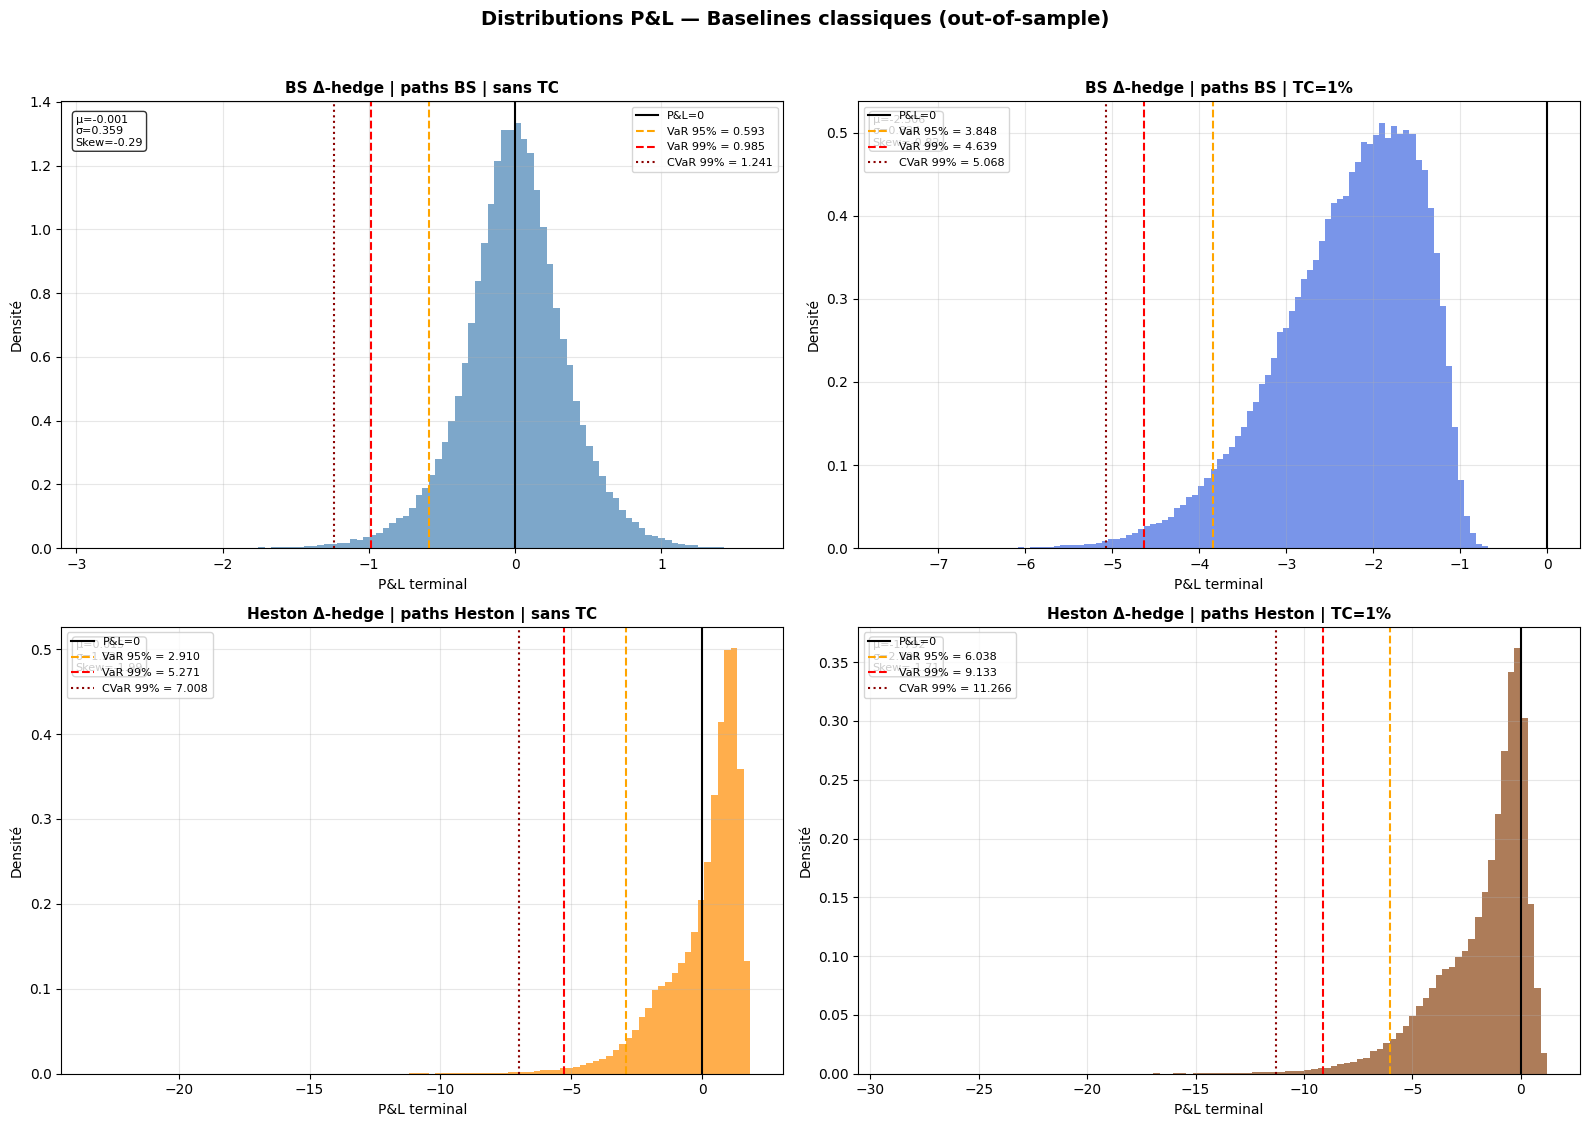

Figure sauvegardée.


In [19]:
# ── Comparaison visuelle des distributions P&L ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

configs = [
    (pnl_bs_notc,  m_bs_notc,  'steelblue',   axes[0, 0], 'BS Δ-hedge | paths BS | sans TC'),
    (pnl_bs_tc,    m_bs_tc,    'royalblue',    axes[0, 1], f'BS Δ-hedge | paths BS | TC={EPS*100:.0f}%'),
    (pnl_hs_notc,  m_hs_notc,  'darkorange',   axes[1, 0], 'Heston Δ-hedge | paths Heston | sans TC'),
    (pnl_hs_tc,    m_hs_tc,    'saddlebrown',  axes[1, 1], f'Heston Δ-hedge | paths Heston | TC={EPS*100:.0f}%'),
]

for pnl, m, color, ax, title in configs:
    ax.hist(pnl, bins=100, density=True, alpha=0.7, color=color, edgecolor='none')
    ax.axvline(0,            color='black',  ls='-',  lw=1.5, label='P&L=0')
    ax.axvline(-m['var95'],  color='orange', ls='--', lw=1.5, label=f'VaR 95% = {m["var95"]:.3f}')
    ax.axvline(-m['var99'],  color='red',    ls='--', lw=1.5, label=f'VaR 99% = {m["var99"]:.3f}')
    ax.axvline(-m['cvar99'], color='darkred',ls=':',  lw=1.5, label=f'CVaR 99% = {m["cvar99"]:.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('P&L terminal')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    # Annotation stats
    ax.text(0.02, 0.97, f'μ={m["mean_pnl"]:.3f}\nσ={m["std_pnl"]:.3f}\nSkew={m["skewness"]:.2f}',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Distributions P&L — Baselines classiques (out-of-sample)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/pnl_distributions_baselines.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée.")

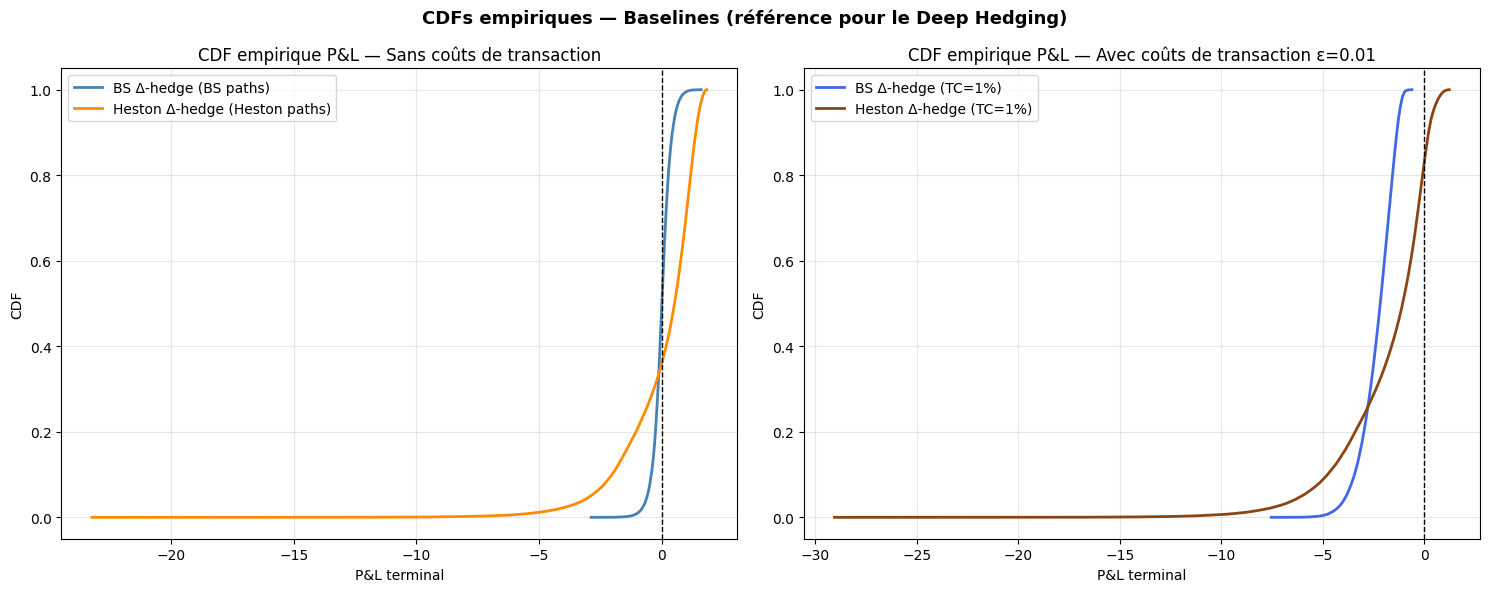

In [20]:
# ── CDFs empiriques (pour comparaison avec Deep Hedging) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_ecdf(ax, pnl, label, color, lw=2):
    sorted_pnl = np.sort(pnl)
    cdf = np.arange(1, len(pnl) + 1) / len(pnl)
    ax.plot(sorted_pnl, cdf, color=color, lw=lw, label=label)

# Sans TC
plot_ecdf(axes[0], pnl_bs_notc, 'BS Δ-hedge (BS paths)', 'steelblue')
plot_ecdf(axes[0], pnl_hs_notc, 'Heston Δ-hedge (Heston paths)', 'darkorange')
axes[0].axvline(0, color='black', ls='--', lw=1)
axes[0].set_title('CDF empirique P&L — Sans coûts de transaction', fontsize=12)
axes[0].set_xlabel('P&L terminal'); axes[0].set_ylabel('CDF')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Avec TC
plot_ecdf(axes[1], pnl_bs_tc, f'BS Δ-hedge (TC={EPS*100:.0f}%)', 'royalblue')
plot_ecdf(axes[1], pnl_hs_tc, f'Heston Δ-hedge (TC={EPS*100:.0f}%)', 'saddlebrown')
axes[1].axvline(0, color='black', ls='--', lw=1)
axes[1].set_title(f'CDF empirique P&L — Avec coûts de transaction ε={EPS}', fontsize=12)
axes[1].set_xlabel('P&L terminal'); axes[1].set_ylabel('CDF')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('CDFs empiriques — Baselines (référence pour le Deep Hedging)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/cdfs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

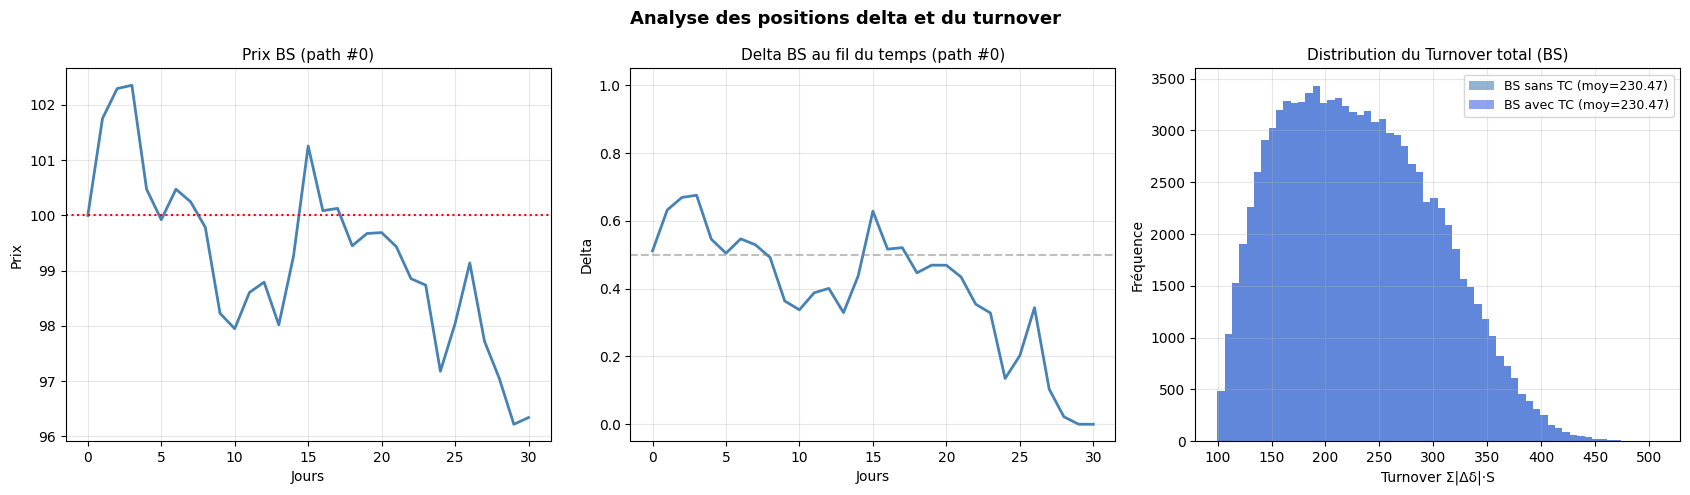

In [21]:
# ── Évolution des deltas : BS vs Heston sur un path typique ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

path_idx = 0  # un path illustratif

# Delta BS
tau_vals  = T - np.arange(N_STEPS + 1) * DT
deltas_bs_1path = bs_delta(S_bs_test[:, path_idx], K, np.maximum(tau_vals, 0), r, SIGMA_BS)

axes[0].plot(t_grid*365, S_bs_test[:, path_idx], color='steelblue', lw=2)
axes[0].axhline(K, color='red', ls=':', lw=1.5)
axes[0].set_title('Prix BS (path #0)', fontsize=11)
axes[0].set_xlabel('Jours'); axes[0].set_ylabel('Prix')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_grid*365, deltas_bs_1path, color='steelblue', lw=2, label='BS Δ')
axes[1].set_title('Delta BS au fil du temps (path #0)', fontsize=11)
axes[1].set_xlabel('Jours'); axes[1].set_ylabel('Delta')
axes[1].set_ylim(-0.05, 1.05)
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# Turnover et coûts de transaction cumulés
axes[2].hist(to_bs_notc, bins=60, alpha=0.6, color='steelblue',
             label=f'BS sans TC (moy={to_bs_notc.mean():.2f})')
axes[2].hist(to_bs_tc, bins=60, alpha=0.6, color='royalblue',
             label=f'BS avec TC (moy={to_bs_tc.mean():.2f})')
axes[2].set_title('Distribution du Turnover total (BS)', fontsize=11)
axes[2].set_xlabel('Turnover Σ|Δδ|·S')
axes[2].set_ylabel('Fréquence')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Analyse des positions delta et du turnover', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/delta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Calcul CVaR vs ε...
  ε=0.000 → CVaR99=1.2409, mean=-0.0012
  ε=0.002 → CVaR99=1.9671, mean=-0.4622
  ε=0.005 → CVaR99=3.1036, mean=-1.1536
  ε=0.010 → CVaR99=5.0684, mean=-2.3060
  ε=0.020 → CVaR99=9.1047, mean=-4.6107
  ε=0.030 → CVaR99=13.2005, mean=-6.9154
  ε=0.050 → CVaR99=21.4476, mean=-11.5249


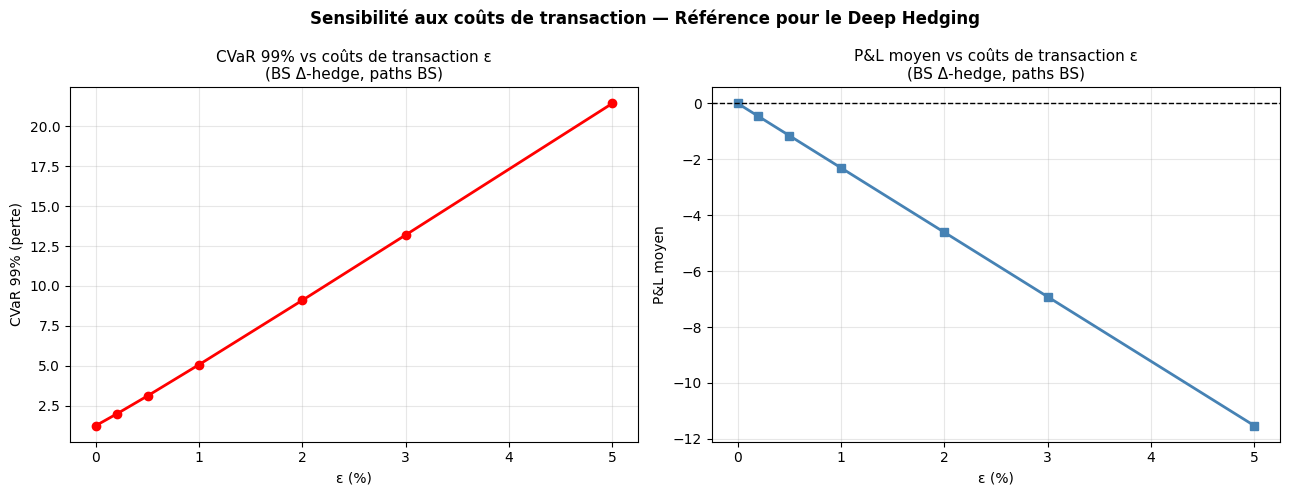

In [22]:
# ── Impact des coûts de transaction sur les métriques de risque ───────────────
eps_range = [0.0, 0.002, 0.005, 0.01, 0.02, 0.03, 0.05]
cvar99_vs_eps = []
mean_pnl_vs_eps = []

print("Calcul CVaR vs ε...")
for eps in eps_range:
    pnl_temp, _, _, _, _ = run_delta_hedge(
        S_bs_test, delta_bs_fn, C0_bs, K, r, T, N_STEPS, eps_tc=eps
    )
    cvar99_vs_eps.append(
        -pnl_temp[pnl_temp <= np.percentile(pnl_temp, 1)].mean()
    )
    mean_pnl_vs_eps.append(pnl_temp.mean())
    print(f"  ε={eps:.3f} → CVaR99={cvar99_vs_eps[-1]:.4f}, mean={mean_pnl_vs_eps[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([e*100 for e in eps_range], cvar99_vs_eps, 'o-', color='red', lw=2)
axes[0].set_title('CVaR 99% vs coûts de transaction ε\n(BS Δ-hedge, paths BS)', fontsize=11)
axes[0].set_xlabel('ε (%)')
axes[0].set_ylabel('CVaR 99% (perte)')
axes[0].grid(True, alpha=0.3)

axes[1].plot([e*100 for e in eps_range], mean_pnl_vs_eps, 's-', color='steelblue', lw=2)
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_title('P&L moyen vs coûts de transaction ε\n(BS Δ-hedge, paths BS)', fontsize=11)
axes[1].set_xlabel('ε (%)')
axes[1].set_ylabel('P&L moyen')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sensibilité aux coûts de transaction — Référence pour le Deep Hedging',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/tc_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — Sauvegarde des données pour les Notebooks 2 et 3

On sauvegarde tous les paths et métriques avec les seeds identiques pour permettre
une comparaison rigoureuse avec le Deep Hedging.

In [23]:
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# Sauvegarde des paths out-of-sample
np.save('/mnt/user-data/outputs/S_bs_test.npy',     S_bs_test)
np.save('/mnt/user-data/outputs/S_heston_test.npy', S_heston_test)
np.save('/mnt/user-data/outputs/V_heston_test.npy', V_heston_test)

# Sauvegarde des métriques baseline (référence pour notebook 3)
import json
baseline_results = {
    'seeds'       : {'train': TRAIN_SEED, 'test': TEST_SEED},
    'params'      : {'T': T, 'n': N_STEPS, 'S0': S0, 'K': K, 'r': r, 'eps_tc': EPS,
                     'sigma_bs': SIGMA_BS,
                     'heston': {'kappa': KAPPA, 'theta': THETA, 'xi': XI,
                                'rho': RHO, 'V0': V0}},
    'option_prices': {'C0_bs': C0_bs, 'C0_heston': C0_heston},
    'metrics' : {m['label']: {k: float(v) for k, v in m.items()
                               if k not in ('label', 'n_paths')}
                 for m in all_metrics}
}

with open('/mnt/user-data/outputs/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

# Sauvegarde des P&L baseline
np.save('/mnt/user-data/outputs/pnl_bs_notc.npy',  pnl_bs_notc)
np.save('/mnt/user-data/outputs/pnl_bs_tc.npy',    pnl_bs_tc)
np.save('/mnt/user-data/outputs/pnl_hs_notc.npy',  pnl_hs_notc)
np.save('/mnt/user-data/outputs/pnl_hs_tc.npy',    pnl_hs_tc)

print("Fichiers sauvegardés :")
for f in ['S_bs_test.npy', 'S_heston_test.npy', 'V_heston_test.npy',
          'baseline_results.json', 'pnl_bs_notc.npy', 'pnl_bs_tc.npy',
          'pnl_hs_notc.npy', 'pnl_hs_tc.npy']:
    path = f'/mnt/user-data/outputs/{f}'
    size = os.path.getsize(path)
    print(f"  {f:<35} {size/1024:.1f} KB")

print("\n✓ Notebook 1 terminé. Données prêtes pour les Notebooks 2 et 3.")

Fichiers sauvegardés :
  S_bs_test.npy                       24218.9 KB
  S_heston_test.npy                   24218.9 KB
  V_heston_test.npy                   24218.9 KB
  baseline_results.json               2.1 KB
  pnl_bs_notc.npy                     781.4 KB
  pnl_bs_tc.npy                       781.4 KB
  pnl_hs_notc.npy                     781.4 KB
  pnl_hs_tc.npy                       781.4 KB

✓ Notebook 1 terminé. Données prêtes pour les Notebooks 2 et 3.


---
## Résumé du Notebook 1

| Composant | Statut | Description |
|-----------|--------|-------------|
| Simulateur GBM (BS) | ✅ | Exact, validé analytiquement |
| Simulateur Heston | ✅ | CIR exact (chi-2 non-centrale), condition Feller vérifiée |
| BS delta (forme fermée) | ✅ | Parité call-put vérifiée |
| Heston delta (FD + grille) | ✅ | Interpolation trilinéaire |
| Coûts de transaction | ✅ | Conformes à Buehler et al. Eq. 5.7 |
| Métriques VaR/CVaR | ✅ | 95% et 99% |
| Comparaison quantitative | ✅ | Table + histogrammes + CDFs |
| Seeds reproductibles | ✅ | `TEST_SEED=2024` partagé |
| Données exportées | ✅ | Prêtes pour Notebooks 2 et 3 |

**→ Notebook 2** : Implémentation du réseau de neurones Deep Hedging  
**→ Notebook 3** : Comparaison out-of-sample complète BS vs Heston vs Deep Hedging